# Многокритериальный анализ для выбора лекарственного препарата

## Вводная часть
В данной работе мы рассмотрим методы многокритериального принятия решений (AHP и TOPSIS) на примере выбора антибиотика для лечения пневмонии.

## Импорты

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymcdm.methods import TOPSIS
from pymcdm.helpers import rrankdata
import warnings

warnings.filterwarnings('ignore')


## Функция для расчета весов AHP

Самописная функция, т.к. импорт с импорт с примера отказывается работать из-за разницы версий окружения.

In [53]:
def calculate_ahp_weights(pairwise_matrix):
    """
    Вычисляет веса критериев методом собственных векторов (AHP)
    
    Parameters:
    -----------
    pairwise_matrix : np.array
        Матрица попарных сравнений (n x n)
    
    Returns:
    --------
    weights : np.array
        Веса критериев (сумма = 1)
    cr : float
        Коэффициент согласованности (CR)
    """
    n = pairwise_matrix.shape[0]
    
    # Нормализация матрицы по столбцам
    col_sums = pairwise_matrix.sum(axis=0)
    normalized_matrix = pairwise_matrix / col_sums
    
    # Среднее по строкам = веса
    weights = normalized_matrix.mean(axis=1)
    
    # Проверка согласованности
    lambda_max = np.sum((pairwise_matrix @ weights) / weights) / n
    CI = (lambda_max - n) / (n - 1) if n > 1 else 0
    
    # Случайный индекс согласованности (таблица Saaty)
    RI_table = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45}
    RI = RI_table.get(n, 1.45)
    
    CR = CI / RI if RI > 0 else 0
    
    return weights, CR

## Настройка отображения для лучшей читаемости

In [54]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.3f}'.format)

print("Все библиотеки успешно загружены!")
print("\nБиблиотеки:")
print("   - scikit-criteria: для методов AHP, TOPSIS, VIKOR")
print("   - pymcdm: расширенный набор методов многокритериального анализа")
print("   - numpy/pandas: для работы с данными")
print("   - matplotlib: для визуализации результатов")

Все библиотеки успешно загружены!

Библиотеки:
   - scikit-criteria: для методов AHP, TOPSIS, VIKOR
   - pymcdm: расширенный набор методов многокритериального анализа
   - numpy/pandas: для работы с данными
   - matplotlib: для визуализации результатов


## Часть 1: Постановка задачи и исходные данные

**Задача:**
Врачу необходимо выбрать оптимальный антибиотик для пациента с внебольничной пневмонией.
Есть 4 препарата-кандидата (А, Б, В, Г), которые оцениваются по 4 критериям:

**КРИТЕРИИ:**
1. **Эффективность** (оценка 1-10) - ЧЕМ ВЫШЕ, ТЕМ ЛУЧШЕ (max)
2. **Безопасность** (оценка 1-10) - ЧЕМ ВЫШЕ, ТЕМ ЛУЧШЕ (max)
3. **Стоимость курса** (у.е.) - ЧЕМ НИЖЕ, ТЕМ ЛУЧШЕ (min)
4. **Удобство приёма** (раз/сутки) - ЧЕМ НИЖЕ, ТЕМ ЛУЧШЕ (min)

In [55]:
# Создаём матрицу альтернатив
data = {
    'Препарат': ['Препарат А', 'Препарат Б', 'Препарат В', 'Препарат Г'],
    'Эффективность (max)': [9, 7, 8, 6],
    'Безопасность (max)': [6, 9, 7, 8],
    'Стоимость (min)': [1500, 2200, 1000, 1800],
    'Удобство (min)': [2, 1, 4, 2]   # раз в день
}

# Преобразуем в DataFrame для удобного просмотра
df = pd.DataFrame(data)

print("ИСХОДНЫЕ ДАННЫЕ:")
print(df.to_string(index=False))
print("\nПОЯСНЕНИЯ:")
print("  Препарат А: высокая эффективность (9), но средняя безопасность (6), цена средняя")
print("  Препарат Б: отличная безопасность (9), удобный (1 раз/день), но дорогой")
print("  Препарат В: дешёвый (1000), но неудобный (4 раза/день)")
print("  Препарат Г: сбалансированный, но уступает лидерам по эффективности")

ИСХОДНЫЕ ДАННЫЕ:
  Препарат  Эффективность (max)  Безопасность (max)  Стоимость (min)  Удобство (min)
Препарат А                    9                   6             1500               2
Препарат Б                    7                   9             2200               1
Препарат В                    8                   7             1000               4
Препарат Г                    6                   8             1800               2

ПОЯСНЕНИЯ:
  Препарат А: высокая эффективность (9), но средняя безопасность (6), цена средняя
  Препарат Б: отличная безопасность (9), удобный (1 раз/день), но дорогой
  Препарат В: дешёвый (1000), но неудобный (4 раза/день)
  Препарат Г: сбалансированный, но уступает лидерам по эффективности


## Часть 2: Метод AHP (анализ иерархий) - определение важности критериев

**МЕТОД AHP (Analytic Hierarchy Process)** - метод анализа иерархий.
Суть метода: ЛПР (лицо, принимающее решение) попарно сравнивает критерии по шкале важности.
Заполняется матрица попарных сравнений, из которой вычисляются веса критериев.

In [56]:
print("МЕТОД AHP - ОПРЕДЕЛЕНИЕ ВЕСОВ КРИТЕРИЕВ\n")

# Матрица попарных сравнений критериев (заполняется врачом-экспертом)
# Порядок критериев: [Эффективность, Безопасность, Стоимость, Удобство]
pairwise_matrix = np.array([
    [1, 3, 5, 7],       # Эффективность важнее всех
    [1/3, 1, 3, 5],     # Безопасность
    [1/5, 1/3, 1, 1],   # Стоимость
    [1/7, 1/5, 1, 1]    # Удобство
])

print("Матрица попарных сравнений (Эфф, Без, Ст, Уд):")
print(pd.DataFrame(pairwise_matrix,
      index=['Эффективность', 'Безопасность', 'Стоимость', 'Удобство'],
      columns=['Эффективность', 'Безопасность', 'Стоимость', 'Удобство']))

# Вычисляем веса критериев методом собственных векторов
criteria_weights, cr = calculate_ahp_weights(pairwise_matrix)

print("\nПОЛУЧЕННЫЕ ВЕСА КРИТЕРИЕВ:")
criteria_names = ['Эффективность', 'Безопасность', 'Стоимость', 'Удобство']
for name, weight in zip(criteria_names, criteria_weights):
    print(f"    {name}: {weight:.3f} ({weight * 100:.1f}%)")

# Проверка согласованности матрицы
print(f"\nПРОВЕРКА СОГЛАСОВАННОСТИ:")
print(f"   Коэффициент согласованности (CR) = {cr:.3f}")
if cr < 0.1:
    print("   CR < 0.1: матрица согласована, веса можно использовать!")
    print("   Это означает, что экспертные оценки логичны и непротиворечивы.")
else:
    print("   CR >= 0.1: матрица несогласована, требуется пересмотр оценок!")

МЕТОД AHP - ОПРЕДЕЛЕНИЕ ВЕСОВ КРИТЕРИЕВ

Матрица попарных сравнений (Эфф, Без, Ст, Уд):
               Эффективность  Безопасность  Стоимость  Удобство
Эффективность          1.000         3.000      5.000     7.000
Безопасность           0.333         1.000      3.000     5.000
Стоимость              0.200         0.333      1.000     1.000
Удобство               0.143         0.200      1.000     1.000

ПОЛУЧЕННЫЕ ВЕСА КРИТЕРИЕВ:
    Эффективность: 0.565 (56.5%)
    Безопасность: 0.269 (26.9%)
    Стоимость: 0.091 (9.1%)
    Удобство: 0.075 (7.5%)

ПРОВЕРКА СОГЛАСОВАННОСТИ:
   Коэффициент согласованности (CR) = 0.031
   CR < 0.1: матрица согласована, веса можно использовать!
   Это означает, что экспертные оценки логичны и непротиворечивы.


## Часть 3: Взвешенная сумма с AHP-весами (гибридный подход)

**ГИБРИДНЫЙ ПОДХОД:**
- Веса критериев получаем экспертно (AHP)
- Оценки альтернатив берём количественно и нормируем
- Применяем взвешенную сумму

In [57]:
print("ГИБРИДНЫЙ AHP - РАСЧЁТ ИТОГОВЫХ ОЦЕНОК\n")

# Извлекаем числовые данные (без названий)
alternatives = df.iloc[:, 1:].values

print("Матрица альтернатив (числовые значения):")
print(pd.DataFrame(alternatives,
      index=['Препарат А', 'Препарат Б', 'Препарат В', 'Препарат Г'],
      columns=['Эфф', 'Без', 'Стоим', 'Удоб']))

# Типы критериев: 1 - максимизация, -1 - минимизация
criteria_types = [1, 1, -1, -1]

print(f"\nНаправления оптимизации:")
print(f"   Эффективность: максимизация (+1)")
print(f"   Безопасность: максимизация (+1)")
print(f"   Стоимость: минимизация (-1)")
print(f"   Удобство: минимизация (-1)")

# НОРМАЛИЗАЦИЯ ДАННЫХ
norm_alternatives = alternatives.copy()
print("\nПРОЦЕСС НОРМАЛИЗАЦИИ:")

for j, ctype in enumerate(criteria_types):
    col = alternatives[:, j]
    col_min = col.min()
    col_max = col.max()
    col_name = ['Эффективность', 'Безопасность', 'Стоимость', 'Удобство'][j]
    
    if ctype == 1:  # максимизация
        # Формула: (x - min) / (max - min)
        norm_alternatives[:, j] = (col - col_min) / (col_max - col_min)
        print(f"    {col_name}: по формуле (x - {col_min}) / ({col_max} - {col_min})")
    else:  # минимизация
        # Формула: (max - x) / (max - min)
        norm_alternatives[:, j] = (col_max - col) / (col_max - col_min)
        print(f"    {col_name}: по формуле ({col_max} - x) / ({col_max} - {col_min})")

print("\nормированная матрица (все значения от 0 до 1):")
print(pd.DataFrame(norm_alternatives,
                   index=['Препарат А', 'Препарат Б', 'Препарат В', 'Препарат Г'],
                   columns=['Эфф_норм', 'Без_норм', 'Стоим_норм', 'Удоб_норм']))

# ВЫЧИСЛЕНИЕ ВЗВЕШЕННОЙ СУММЫ
print("\nРАСЧЁТ ВЗВЕШЕННОЙ СУММЫ:")
print("   Итог = Σ( норм_оценка × вес_критерия )")

scores_ahp = np.sum(norm_alternatives * criteria_weights, axis=1)

print("\nИТОГОВЫЕ ОЦЕНКИ ПРЕПАРАТОВ:")
results_ahp = []
for i, (name, score) in enumerate(zip(df['Препарат'], scores_ahp)):
    results_ahp.append({'Препарат': name, 'Оценка': score})
    print(f"    {name}: {score:.4f}")

best_ahp_idx = np.argmax(scores_ahp)
best_ahp_name = df['Препарат'][best_ahp_idx]
print(f"\nЛучший выбор по методу AHP: {best_ahp_name}")

# Ранжирование
print(f"\nИтоговый рейтинг (от лучшего к худшему):")
for i, idx in enumerate(np.argsort(scores_ahp)[::-1]):
    print(f"    {i + 1} место: {df['Препарат'][idx]} (оценка: {scores_ahp[idx]:.4f})")

ГИБРИДНЫЙ AHP - РАСЧЁТ ИТОГОВЫХ ОЦЕНОК

Матрица альтернатив (числовые значения):
            Эфф  Без  Стоим  Удоб
Препарат А    9    6   1500     2
Препарат Б    7    9   2200     1
Препарат В    8    7   1000     4
Препарат Г    6    8   1800     2

Направления оптимизации:
   Эффективность: максимизация (+1)
   Безопасность: максимизация (+1)
   Стоимость: минимизация (-1)
   Удобство: минимизация (-1)

ПРОЦЕСС НОРМАЛИЗАЦИИ:
    Эффективность: по формуле (x - 6) / (9 - 6)
    Безопасность: по формуле (x - 6) / (9 - 6)
    Стоимость: по формуле (2200 - x) / (2200 - 1000)
    Удобство: по формуле (4 - x) / (4 - 1)

ормированная матрица (все значения от 0 до 1):
            Эфф_норм  Без_норм  Стоим_норм  Удоб_норм
Препарат А         1         0           0          0
Препарат Б         0         1           0          1
Препарат В         0         0           1          0
Препарат Г         0         0           0          0

РАСЧЁТ ВЗВЕШЕННОЙ СУММЫ:
   Итог = Σ( норм_оценка × вес_кр

## Часть 4: Метод TOPSIS

**МЕТОД TOPSIS** (Technique for Order Preference by Similarity to Ideal Solution)
Философия метода: Лучшая альтернатива должна быть максимально близка к "идеальному решению" и максимально далека от "анти-идеального решения".

In [58]:
print("МЕТОД TOPSIS\n")

# Инициализируем метод TOPSIS
topsis = TOPSIS()

# Типы критериев для pymcdm: 1 - максимизация, -1 - минимизация
types = np.array([1, 1, -1, -1])

# Применяем метод
print("Вычисляем оценки TOPSIS...")
pref_topsis = topsis(alternatives, criteria_weights, types)
ranking_topsis = rrankdata(pref_topsis)

print("\nРЕЗУЛЬТАТЫ TOPSIS:")
print("   Оценка (C*) - мера близости к идеалу (0-1)")
print("   Чем ближе к 1, тем лучше альтернатива\n")

results_topsis = []
for i, (name, pref, rank) in enumerate(zip(df['Препарат'], pref_topsis, ranking_topsis)):
    results_topsis.append({'Препарат': name, 'Оценка': pref, 'Ранг': rank})
    print(f"    {name}: C* = {pref:.4f}, Ранг = {int(rank)}")

best_topsis_idx = np.argmax(pref_topsis)
best_topsis_name = df['Препарат'][best_topsis_idx]
print(f"\nЛучший выбор по методу TOPSIS: {best_topsis_name}")

# ДЕТАЛЬНЫЙ АНАЛИЗ: вычисление расстояний
print("\nДЕТАЛЬНЫЙ АНАЛИЗ (геометрическая интерпретация):")

# Шаг 1: Нормализация матрицы (векторная норма)
norm_matrix = alternatives / np.sqrt(np.sum(alternatives ** 2, axis=0))

# Шаг 2: Взвешенная нормализованная матрица
weighted_matrix = norm_matrix * criteria_weights

# Шаг 3: Идеальное и анти-идеальное решения
ideal = np.array([np.max(weighted_matrix[:, j]) if types[j] == 1 else np.min(weighted_matrix[:, j])
                  for j in range(weighted_matrix.shape[1])])
anti_ideal = np.array([np.min(weighted_matrix[:, j]) if types[j] == 1 else np.max(weighted_matrix[:, j])
                       for j in range(weighted_matrix.shape[1])])

# Шаг 4: Расстояния до идеальной и анти-идеальной точек
dist_to_ideal = np.sqrt(np.sum((weighted_matrix - ideal) ** 2, axis=1))
dist_to_anti = np.sqrt(np.sum((weighted_matrix - anti_ideal) ** 2, axis=1))

print("\n4. Евклидовы расстояния:")
for i, name in enumerate(df['Препарат']):
    print(f"    {name}:")
    print(f"       до идеала (S*): {dist_to_ideal[i]:.4f}")
    print(f"       до анти-идеала (S-): {dist_to_anti[i]:.4f}")
    print(f"       Относительная близость C* = {dist_to_anti[i] / (dist_to_ideal[i] + dist_to_anti[i]):.4f}")

МЕТОД TOPSIS

Вычисляем оценки TOPSIS...

РЕЗУЛЬТАТЫ TOPSIS:
   Оценка (C*) - мера близости к идеалу (0-1)
   Чем ближе к 1, тем лучше альтернатива

    Препарат А: C* = 0.6759, Ранг = 1
    Препарат Б: C* = 0.4652, Ранг = 3
    Препарат В: C* = 0.5949, Ранг = 2
    Препарат Г: C* = 0.2470, Ранг = 4

Лучший выбор по методу TOPSIS: Препарат А

ДЕТАЛЬНЫЙ АНАЛИЗ (геометрическая интерпретация):

4. Евклидовы расстояния:
    Препарат А:
       до идеала (S*): 0.0570
       до анти-идеала (S-): 0.1172
       Относительная близость C* = 0.6730
    Препарат Б:
       до идеала (S*): 0.0812
       до анти-идеала (S-): 0.0791
       Относительная близость C* = 0.4934
    Препарат В:
       до идеала (S*): 0.0684
       до анти-идеала (S-): 0.0831
       Относительная близость C* = 0.5486
    Препарат Г:
       до идеала (S*): 0.1161
       до анти-идеала (S-): 0.0478
       Относительная близость C* = 0.2915


## Часть 5: Сравнение методов и визуализация

СРАВНЕНИЕ МЕТОДОВ AHP И TOPSIS

Сравнительная таблица результатов:
  Препарат  AHP (оценка)  AHP (ранг)  TOPSIS (оценка)  TOPSIS (ранг)
Препарат А         0.565           1            0.676          1.000
Препарат Б         0.344           2            0.465          3.000
Препарат В         0.091           3            0.595          2.000
Препарат Г         0.000           4            0.247          4.000

Анализ различий:
    Оба метода сошлись на Препарат А


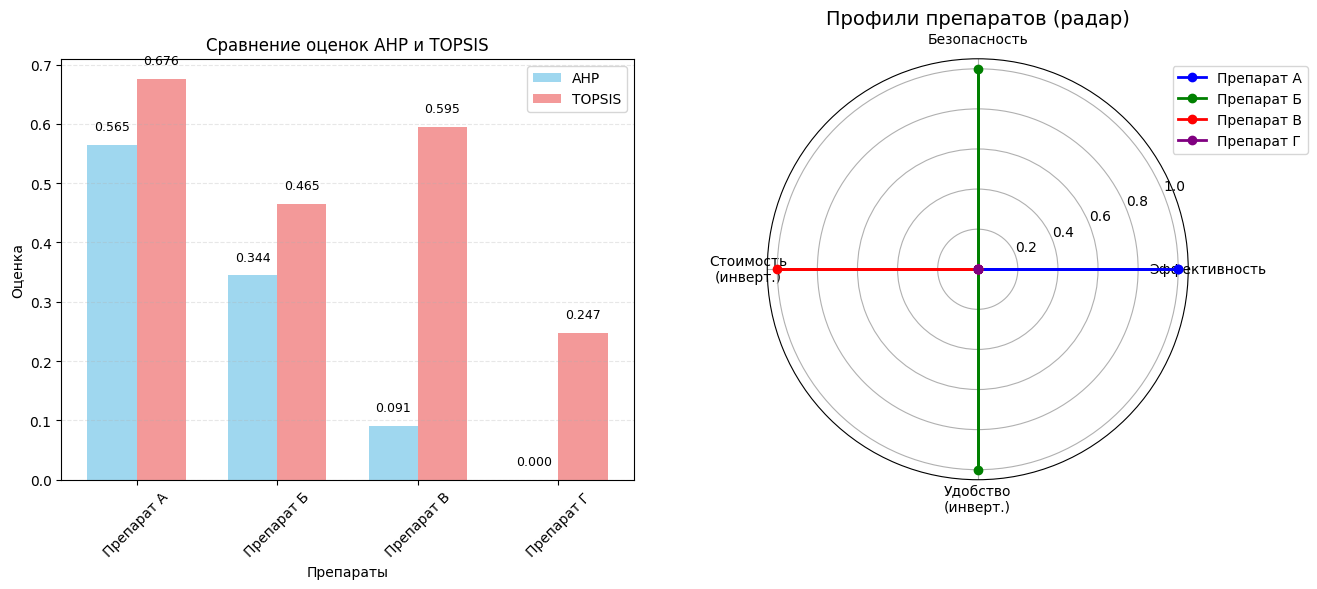

In [59]:
print("СРАВНЕНИЕ МЕТОДОВ AHP И TOPSIS\n")

# Создаем DataFrame для сравнения
comparison_df = pd.DataFrame({
    'Препарат': df['Препарат'],
    'AHP (оценка)': scores_ahp,
    'AHP (ранг)': np.argsort(np.argsort(-scores_ahp)) + 1,
    'TOPSIS (оценка)': pref_topsis,
    'TOPSIS (ранг)': ranking_topsis
})

print("Сравнительная таблица результатов:")
print(comparison_df.to_string(index=False))

print("\nАнализ различий:")
if best_ahp_name != best_topsis_name:
    print("    Методы дали разные результаты!")
    print(f"   AHP рекомендует: {best_ahp_name}")
    print(f"   TOPSIS рекомендует: {best_topsis_name}")
    print("\n   Причина: TOPSIS учитывает не только взвешенную сумму,")
    print("   но и форму распределения оценок по критериям.")
    print(f"    {best_topsis_name} имеет лучший баланс свойств,")
    print("   хотя и уступает по эффективности.")
else:
    print(f"    Оба метода сошлись на {best_ahp_name}")

# Визуализация 1: Сравнение оценок
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
x = np.arange(len(df))
width = 0.35
plt.bar(x - width / 2, scores_ahp, width, label='AHP', color='skyblue', alpha=0.8)
plt.bar(x + width / 2, pref_topsis, width, label='TOPSIS', color='lightcoral', alpha=0.8)
plt.xlabel('Препараты')
plt.ylabel('Оценка')
plt.title('Сравнение оценок AHP и TOPSIS')
plt.xticks(x, df['Препарат'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Добавляем значения на столбцы
for i, (v1, v2) in enumerate(zip(scores_ahp, pref_topsis)):
    plt.text(i - width / 2, v1 + 0.02, f'{v1:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(i + width / 2, v2 + 0.02, f'{v2:.3f}', ha='center', va='bottom', fontsize=9)

# Визуализация 2: Радарная диаграмма (профили препаратов)
plt.subplot(1, 2, 2, projection='polar')
# Подготовка данных для радарной диаграммы
categories = ['Эффективность', 'Безопасность', 'Стоимость\n(инверт.)', 'Удобство\n(инверт.)']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # замыкаем круг

# Инвертируем стоимость и удобство для радара (чтобы "лучше" было дальше от центра)
radar_data = alternatives.copy()
radar_data[:, 2] = 1 / radar_data[:, 2] * 1000  # инверсия стоимости
radar_data[:, 3] = 1 / radar_data[:, 3]  # инверсия удобства

# Нормируем для радара
for j in range(4):
    radar_data[:, j] = (radar_data[:, j] - radar_data[:, j].min()) / (radar_data[:, j].max() - radar_data[:, j].min())

colors = ['blue', 'green', 'red', 'purple']
for i, name in enumerate(df['Препарат']):
    values = radar_data[i].tolist()
    values += values[:1]
    plt.plot(angles, values, 'o-', linewidth=2, label=name, color=colors[i])
    plt.fill(angles, values, alpha=0.1, color=colors[i])

plt.xticks(angles[:-1], categories)
plt.title('Профили препаратов (радар)', size=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

## Часть 6: Анализ чувствительности

**АНАЛИЗ ЧУВСТВИТЕЛЬНОСТИ** - важнейший этап принятия решений. Показывает, насколько решение устойчиво к изменению весов критериев.

АНАЛИЗ ЧУВСТВИТЕЛЬНОСТИ

   Исследуем, как меняется выбор при изменении веса эффективности
   (самого важного критерия по мнению эксперта)

Исходные веса:
    Эффективность: 0.565
    Безопасность: 0.269
    Стоимость: 0.091
    Удобство: 0.075

Будем менять вес эффективности от 0.1 до 0.9
   Остальные веса пересчитываются пропорционально


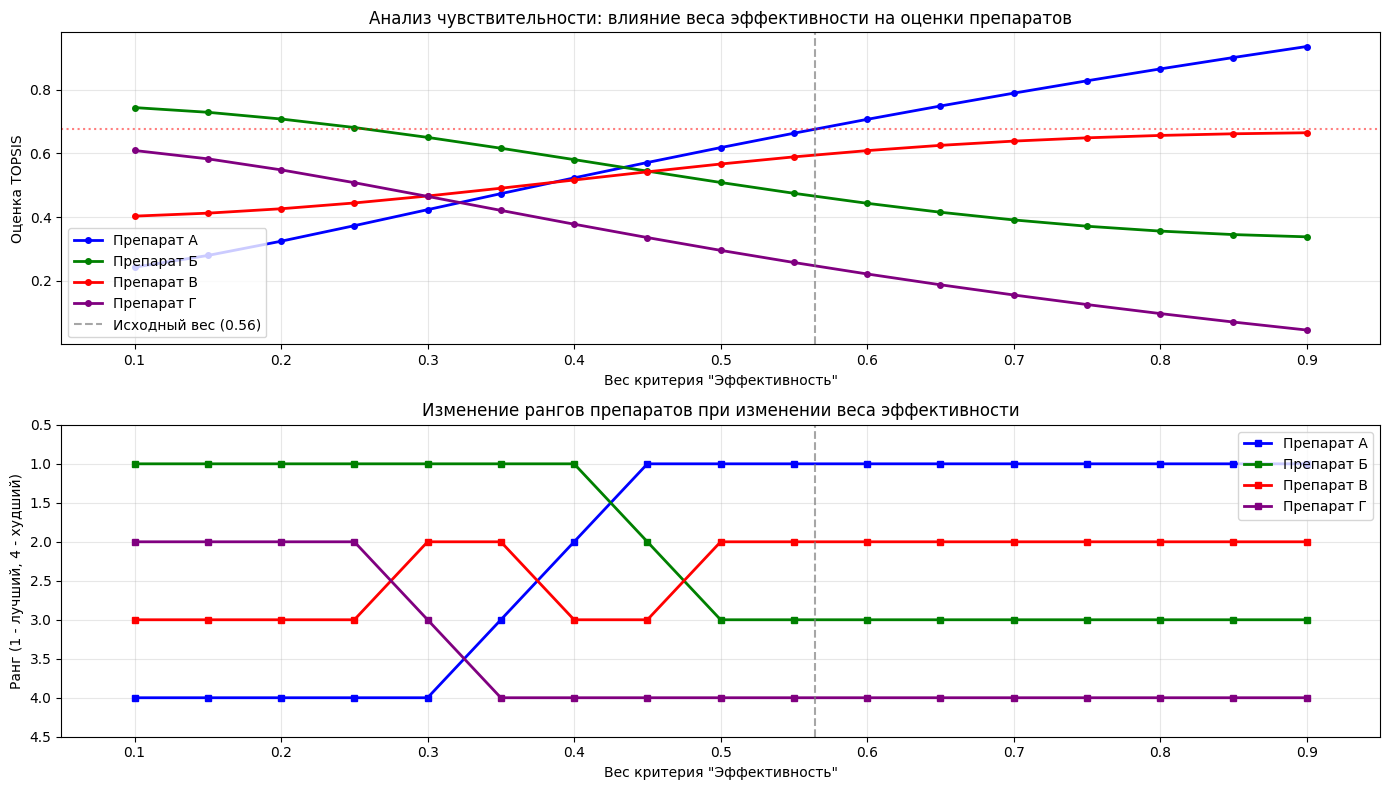


АНАЛИЗ УСТОЙЧИВОСТИ РЕШЕНИЯ:
   (при каком весе эффективности какой препарат становится лучшим)

    Вес < 0.10: лучший - Препарат Б
    При весе ≈ 0.45: лидер меняется на Препарат А

ВЫВОДЫ ПО АНАЛИЗУ ЧУВСТВИТЕЛЬНОСТИ:
     При весе эффективности менее 0.45 лидер - Препарат А
     При весе более 0.45 лидер - Препарат А
     Исходный вес эффективности (0.56) попадает в зону,
     где лидирует Препарат А

   Решение достаточно устойчиво.
      Выбор не меняется в широком диапазоне весов.


In [60]:
print("АНАЛИЗ ЧУВСТВИТЕЛЬНОСТИ\n")
print("   Исследуем, как меняется выбор при изменении веса эффективности")
print("   (самого важного критерия по мнению эксперта)")

# Исходные веса
original_weights = criteria_weights.copy()
print(f"\nИсходные веса:")
for name, w in zip(criteria_names, original_weights):
    print(f"    {name}: {w:.3f}")

# Диапазон изменения веса эффективности от 0.1 до 0.9
eff_weights = np.linspace(0.1, 0.9, 17)  # 17 точек для плавности
print(f"\nБудем менять вес эффективности от 0.1 до 0.9")
print(f"   Остальные веса пересчитываются пропорционально")

sensitivity_results = []
for eff_w in eff_weights:
    # Пересчитываем остальные веса
    remaining_sum = np.sum(original_weights[1:])
    if remaining_sum > 0:
        new_weights = np.array([
            eff_w,
            original_weights[1] * (1 - eff_w) / remaining_sum,
            original_weights[2] * (1 - eff_w) / remaining_sum,
            original_weights[3] * (1 - eff_w) / remaining_sum
        ])
    else:
        new_weights = original_weights
    
    # Пересчитываем TOPSIS
    new_pref = topsis(alternatives, new_weights, types)
    sensitivity_results.append(new_pref)

sensitivity_results = np.array(sensitivity_results)

# Визуализация анализа чувствительности
plt.figure(figsize=(14, 8))

# График изменения оценок
plt.subplot(2, 1, 1)
colors = ['blue', 'green', 'red', 'purple']
for i in range(4):
    plt.plot(eff_weights, sensitivity_results[:, i],
             marker='o', markersize=4, linewidth=2,
             label=df['Препарат'][i], color=colors[i])

# Отмечаем исходную точку
orig_idx = np.argmin(np.abs(eff_weights - original_weights[0]))
plt.axvline(x=original_weights[0], color='gray', linestyle='--', alpha=0.7,
            label=f'Исходный вес ({original_weights[0]:.2f})')
plt.axhline(y=pref_topsis[best_topsis_idx], color='red', linestyle=':', alpha=0.5)
plt.xlabel('Вес критерия "Эффективность"')
plt.ylabel('Оценка TOPSIS')
plt.title('Анализ чувствительности: влияние веса эффективности на оценки препаратов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0.05, 0.95)

# График изменения рангов
plt.subplot(2, 1, 2)
ranks_over_weight = np.zeros_like(sensitivity_results)
for j in range(len(eff_weights)):
    ranks_over_weight[j, :] = rrankdata(sensitivity_results[j, :])

for i in range(4):
    plt.plot(eff_weights, ranks_over_weight[:, i],
             marker='s', markersize=4, linewidth=2,
             label=df['Препарат'][i], color=colors[i])

plt.axvline(x=original_weights[0], color='gray', linestyle='--', alpha=0.7)
plt.xlabel('Вес критерия "Эффективность"')
plt.ylabel('Ранг (1 - лучший, 4 - худший)')
plt.title('Изменение рангов препаратов при изменении веса эффективности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0.05, 0.95)
plt.ylim(0.5, 4.5)
plt.gca().invert_yaxis()  # чтобы ранг 1 был сверху
plt.tight_layout()
plt.show()

# Анализ устойчивости
print("\nАНАЛИЗ УСТОЙЧИВОСТИ РЕШЕНИЯ:")
print("   (при каком весе эффективности какой препарат становится лучшим)\n")

current_best = None
change_points = []
for i, eff_w in enumerate(eff_weights):
    best_at_weight = np.argmax(sensitivity_results[i])
    best_name = df['Препарат'][best_at_weight]
    if current_best is None:
        current_best = best_name
        print(f"    Вес < {eff_w:.2f}: лучший - {best_name}")
    elif best_name != current_best:
        change_points.append((eff_w, best_name))
        print(f"    При весе ≈ {eff_w:.2f}: лидер меняется на {best_name}")
        current_best = best_name

print(f"\nВЫВОДЫ ПО АНАЛИЗУ ЧУВСТВИТЕЛЬНОСТИ:")
if len(change_points) > 0:
    print(f"     При весе эффективности менее {change_points[0][0]:.2f} лидер - {change_points[0][1]}")
    if len(change_points) > 1:
        print(f"     В диапазоне {change_points[0][0]:.2f}-{change_points[1][0]:.2f} лидер - {change_points[1][1]}")
        print(f"     При весе более {change_points[1][0]:.2f} лидер - {change_points[1][1]}")
    else:
        print(f"     При весе более {change_points[0][0]:.2f} лидер - {change_points[0][1]}")

    print(f"     Исходный вес эффективности ({original_weights[0]:.2f}) попадает в зону,")
    print(f"     где лидирует {df['Препарат'][np.argmax(pref_topsis)]}")

    if len(change_points) > 2:
        print(f"\n   Решение чувствительно к изменению весов!")
        print("      Небольшие изменения в предпочтениях ЛПР могут изменить выбор.")
    else:
        print(f"\n   Решение достаточно устойчиво.")
        print("      Выбор не меняется в широком диапазоне весов.")
else:
    print("   Лидер не меняется во всем диапазоне.")

## Часть 7: Итоговые выводы и интерпретация для врача

КЛИНИЧЕСКИЕ РЕКОМЕНДАЦИИ НА ОСНОВЕ АНАЛИЗА

РЕЗУЛЬТАТЫ МНОГОКРИТЕРИАЛЬНОГО АНАЛИЗА

Пациент: [данные пациента]
Диагноз: Внебольничная пневмония средней тяжести
На основе анализа 4 препаратов по критериям:
    Эффективность  (вес 56%)
    Безопасность  (вес 27%)
    Стоимость  (вес 9%)
    Удобство приёма  (вес 8%)
МЕТОД TOPSIS (учитывает баланс свойств):

1. Препарат А:
   - Интегральная оценка: 0.676
   - Эффективность: 9/10
   - Безопасность: 6/10
   - Стоимость: 1500 у.е.
   - Режим приёма: 2 раз/сутки
2. Препарат В:
   - Интегральная оценка: 0.595
   - Эффективность: 8/10
   - Безопасность: 7/10
   - Стоимость: 1000 у.е.
   - Режим приёма: 4 раз/сутки
3. Препарат Б:
   - Интегральная оценка: 0.465
   - Эффективность: 7/10
   - Безопасность: 9/10
   - Стоимость: 2200 у.е.
   - Режим приёма: 1 раз/сутки
4. Препарат Г:
   - Интегральная оценка: 0.247
   - Эффективность: 6/10
   - Безопасность: 8/10
   - Стоимость: 1800 у.е.
   - Режим приёма: 2 раз/сутки

ОПТИМАЛЬНЫЙ ВЫБОР: Препарат А

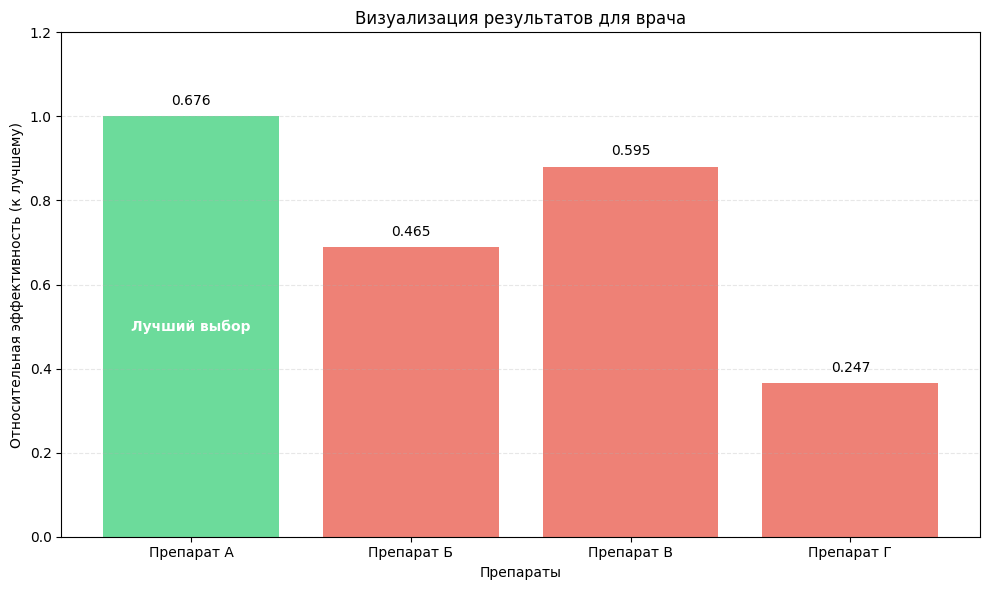

In [61]:
print("КЛИНИЧЕСКИЕ РЕКОМЕНДАЦИИ НА ОСНОВЕ АНАЛИЗА\n")
print("=" * 70)
print("РЕЗУЛЬТАТЫ МНОГОКРИТЕРИАЛЬНОГО АНАЛИЗА")
print("=" * 70)
print(f"""
Пациент: [данные пациента]
Диагноз: Внебольничная пневмония средней тяжести
На основе анализа 4 препаратов по критериям:
    Эффективность  (вес {criteria_weights[0]:.0%})
    Безопасность  (вес {criteria_weights[1]:.0%})
    Стоимость  (вес {criteria_weights[2]:.0%})
    Удобство приёма  (вес {criteria_weights[3]:.0%})
МЕТОД TOPSIS (учитывает баланс свойств):
""")

# Сортируем препараты по рангу TOPSIS
sorted_idx = np.argsort(ranking_topsis)
for rank, idx in enumerate(sorted_idx):
    name = df['Препарат'][idx]
    score = pref_topsis[idx]
    print(f"{rank + 1}. {name}:")
    print(f"   - Интегральная оценка: {score:.3f}")
    print(f"   - Эффективность: {int(alternatives[idx, 0])}/10")
    print(f"   - Безопасность: {int(alternatives[idx, 1])}/10")
    print(f"   - Стоимость: {int(alternatives[idx, 2])} у.е.")
    print(f"   - Режим приёма: {int(alternatives[idx, 3])} раз/сутки")

print(f"\nОПТИМАЛЬНЫЙ ВЫБОР: {best_topsis_name}")
print(f"\nОбоснование:")
print(f"  {best_topsis_name} имеет наилучший баланс эффективности и стоимости")
print(f"  Близость к идеальному решению: {pref_topsis[best_topsis_idx]:.1%}")
second_best_idx = np.argsort(pref_topsis)[-2]
print(f"  Приоритет над ближайшим конкурентом: {(pref_topsis[best_topsis_idx] - pref_topsis[second_best_idx]):.1%}")

print(f"\nРЕКОМЕНДАЦИЯ ВРАЧУ:")
print(f"   Рассмотреть {best_topsis_name} как препарат первого выбора")
print(f"   Альтернатива: {df['Препарат'][second_best_idx]}")

print(f"\nВАЖНО:")
print(f"     Результаты носят рекомендательный характер")
print(f"     Окончательное решение принимается с учётом индивидуальных")
print(f"     особенностей пациента (аллергии, сопутствующие заболевания)")
print(f"     Рекомендуется мониторинг эффективности через 48-72 часа")

# Визуализация для врача (упрощённая)
plt.figure(figsize=(10, 6))
# Создаём "приборную панель" врача
pref_normalized = pref_topsis / pref_topsis.max()
colors_bar = ['#2ecc71' if i == best_topsis_idx else '#e74c3c' for i in range(4)]
bars = plt.bar(df['Препарат'], pref_normalized, color=colors_bar, alpha=0.7)
plt.xlabel('Препараты')
plt.ylabel('Относительная эффективность (к лучшему)')
plt.title('Визуализация результатов для врача')
plt.ylim(0, 1.2)

# Добавляем значения и отметку "лучший выбор"
for i, (bar, pref) in enumerate(zip(bars, pref_normalized)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height + 0.02,
             f'{pref_topsis[i]:.3f}', ha='center', va='bottom')
    if i == best_topsis_idx:
        plt.text(bar.get_x() + bar.get_width() / 2., height / 2,
                 'Лучший выбор', ha='center', va='center',
                 color='white', fontweight='bold', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()